In [13]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI

load_dotenv()  # 加载.env文件里的变量
# print(os.getenv("DEEPSEEK_API_KEY"))  # 现在可以正常读取了

llm = ChatOpenAI(
        model="deepseek-chat",  # 使用的模型名称，目前官方推荐用 'deepseek-chat'
        api_key=os.getenv("DEEPSEEK_API_KEY"),  # 你的 DeepSeek API Key
        base_url="https://api.deepseek.com/v1",  # DeepSeek API 地址
        temperature=0,
    )

In [14]:
from typing import Union,Optional
from pydantic import BaseModel,Field

class UserInfo(BaseModel):
    name: str=Field(description="The name of the user")
    age: Optional[int]=Field(description="The age of the user")
    email:str=Field(description="The email address of the user")
    phone:Optional[str]=Field(description="The phone number of the usser")

class ConversationalResponse(BaseModel):
    response:str =Field(description="A conversation response to the user's query")

class FinalResponse(BaseModel):
    final_output:Union[UserInfo,ConversationalResponse]

In [15]:
# ❌ DeepSeek 不支持 with_structured_output（依赖 response_format 参数）
# structured_llm = llm.with_structured_output(UserInfo)

# ✅ 改用 PydanticOutputParser — 把 schema 注入 prompt，不依赖 API 原生能力
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import ChatPromptTemplate

parser = PydanticOutputParser(pydantic_object=FinalResponse)

prompt = ChatPromptTemplate.from_messages([
    ("system", "解析用户输入并提取个人信息。\n{format_instructions}"),
    ("human", "{query}"),
])

# 把 Pydantic schema 的格式化指令注入 prompt
prompt = prompt.partial(format_instructions=parser.get_format_instructions())

structured_llm = prompt | llm | parser

In [16]:
extracted_user_info=structured_llm.invoke("我叫奥特曼，今年38岁，邮箱地址是aoteman@qq.com,电话是123123123")

In [17]:
extracted_user_info

FinalResponse(final_output=UserInfo(name='奥特曼', age=38, email='aoteman@qq.com', phone='123123123'))

In [18]:
if isinstance(extracted_user_info,UserInfo):
    print("执行节点A的逻辑")
else:
    print("执行节点B的逻辑")

执行节点B的逻辑


In [19]:
extracted_user_info=structured_llm.invoke("你好")

if isinstance(extracted_user_info,UserInfo):
    print("执行节点A的逻辑")
else:
    print("执行节点B的逻辑")

执行节点B的逻辑


In [21]:
extracted_user_info.final_output.response

'你好！有什么我可以帮助你的吗？'

In [22]:
extracted_user_info=structured_llm.invoke("我叫奥特曼，今年38岁，邮箱地址是aoteman@qq.com,电话是123123123")

In [23]:
extracted_user_info.final_output

UserInfo(name='奥特曼', age=38, email='aoteman@qq.com', phone='123123123')

pip install sqlalchemy pymysql

In [25]:
from sqlalchemy import create_engine, Table, Column, Integer, String, MetaData
from sqlalchemy.orm import declarative_base, sessionmaker
import pymysql  # ✅ 显式导入，让 SQLAlchemy 识别

# 创建基类
Base = declarative_base()

class User(Base):
    __tablename__ = 'users'
    id = Column(Integer, primary_key=True)
    name = Column(String(50))
    age = Column(Integer)
    email = Column(String(100))
    phone = Column(String(15))

# ✅ mysql:// → mysql+pymysql://，用 PyMySQL 驱动
DATABASE_URI = os.getenv("DATABASE_URI")
engine = create_engine(DATABASE_URI, echo=True)

Base.metadata.create_all(engine)

Session = sessionmaker(bind=engine)
session = Session()

2026-06-11 22:32:33,751 INFO sqlalchemy.engine.Engine SELECT DATABASE()
2026-06-11 22:32:33,752 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-11 22:32:33,754 INFO sqlalchemy.engine.Engine SELECT @@sql_mode
2026-06-11 22:32:33,755 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-11 22:32:33,756 INFO sqlalchemy.engine.Engine SELECT @@lower_case_table_names
2026-06-11 22:32:33,757 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-11 22:32:33,759 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-11 22:32:33,759 INFO sqlalchemy.engine.Engine DESCRIBE `langgraph`.`users`
2026-06-11 22:32:33,760 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-11 22:32:33,765 INFO sqlalchemy.engine.Engine 
CREATE TABLE users (
	id INTEGER NOT NULL AUTO_INCREMENT, 
	name VARCHAR(50), 
	age INTEGER, 
	email VARCHAR(100), 
	phone VARCHAR(15), 
	PRIMARY KEY (id)
)


2026-06-11 22:32:33,765 INFO sqlalchemy.engine.Engine [no key 0.00082s] {}
2026-06-11 22:32:33,803 INFO sqlalchemy.engine.Engine COMMI

In [26]:
def chat_with_model(state):
    print(state)
    print("--------------------------")
    messages=state['messages']
    response=structured_llm.invoke(messages)
    return {"messages":[response]}

In [27]:
def final_answer(state):
    print(state)
    print("---------------------")
    messages=state["messages"][-1]
    response=messages.final_output.response
    return {"messages":[response]}

def insert_db(state):
    session=Session()
    try:
        result=state["messages"][-1]
        output=result.final_output
        user=User(name=output.name,age=output.age,email=output.email,phone=output.phone)
        session.add(user)
        session.commit()
        return {"messages":[f"数据已成功存储到mysql数据库"]}
    except Exception as e:
        session.rollback()
        return {"messages":[f"数据存储失败，错误原因:{e}"]}
    finally:
        session.close()


In [28]:
from langgraph.graph import StateGraph,END
from typing import TypedDict,Annotated
import operator
from langchain_core.messages import AnyMessage,SystemMessage,HumanMessage,ToolMessage

In [29]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage],operator.add]

In [30]:
def generate_branch(state:AgentState):
    result=state["messages"][-1]
    output=result.final_output

    if isinstance(output, UserInfo):
        return True
    elif isinstance(output,ConversationalResponse):
        return False

In [32]:
graph=StateGraph(AgentState)

graph.add_node("chat_with_model",chat_with_model)
graph.add_node("final_answer",final_answer)
graph.add_node("insert_db",insert_db)

graph.set_entry_point("chat_with_model")

graph.add_conditional_edges(
    "chat_with_model", generate_branch,
    {
        True:"insert_db",
        False:"final_answer"
    }
)

graph.set_finish_point("final_answer")
graph.set_finish_point("insert_db")

graph=graph.compile()

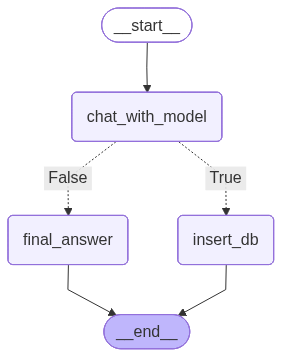

In [33]:
from IPython.display import Image,display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [34]:
query="我叫奥特曼，今年38岁，邮箱地址是aoteman@qq.com,电话是123123123"
input_message={"messages":[HumanMessage(content=query)]}

result=graph.invoke(input_message)
result

{'messages': [HumanMessage(content='我叫奥特曼，今年38岁，邮箱地址是aoteman@qq.com,电话是123123123', additional_kwargs={}, response_metadata={})]}
--------------------------
2026-06-11 22:57:02,279 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-11 22:57:02,281 INFO sqlalchemy.engine.Engine INSERT INTO users (name, age, email, phone) VALUES (%(name)s, %(age)s, %(email)s, %(phone)s)
2026-06-11 22:57:02,282 INFO sqlalchemy.engine.Engine [generated in 0.00077s] {'name': '奥特曼', 'age': 38, 'email': 'aoteman@qq.com', 'phone': '123123123'}
2026-06-11 22:57:02,288 INFO sqlalchemy.engine.Engine COMMIT


{'messages': [HumanMessage(content='我叫奥特曼，今年38岁，邮箱地址是aoteman@qq.com,电话是123123123', additional_kwargs={}, response_metadata={}),
  FinalResponse(final_output=UserInfo(name='奥特曼', age=38, email='aoteman@qq.com', phone='123123123')),
  '数据已成功存储到mysql数据库']}

In [35]:
result["messages"][-1]

'数据已成功存储到mysql数据库'

In [37]:
query="你好，介绍一下你自己"
result=graph.invoke({"messages":[HumanMessage(content=query)]})
result["messages"][-1]

{'messages': [HumanMessage(content='你好，介绍一下你自己', additional_kwargs={}, response_metadata={})]}
--------------------------
{'messages': [HumanMessage(content='你好，介绍一下你自己', additional_kwargs={}, response_metadata={}), FinalResponse(final_output=ConversationalResponse(response='你好！我是AI助手，可以帮你处理各种问题。请问有什么可以帮你的吗？'))]}
---------------------


'你好！我是AI助手，可以帮你处理各种问题。请问有什么可以帮你的吗？'

In [39]:
query="请问什么是机器学习"
result=graph.invoke({"messages":[HumanMessage(content=query)]})
result["messages"][-1]

{'messages': [HumanMessage(content='请问什么是机器学习', additional_kwargs={}, response_metadata={})]}
--------------------------
{'messages': [HumanMessage(content='请问什么是机器学习', additional_kwargs={}, response_metadata={}), FinalResponse(final_output=ConversationalResponse(response='机器学习是一种人工智能技术，它使计算机能够从数据中学习并做出决策或预测，而无需进行明确的编程。'))]}
---------------------


'机器学习是一种人工智能技术，它使计算机能够从数据中学习并做出决策或预测，而无需进行明确的编程。'

In [41]:
result=graph.invoke({"messages":[HumanMessage(content="我叫孙悟空，今年500岁，邮箱是13212321312")]})

result

{'messages': [HumanMessage(content='我叫孙悟空，今年500岁，邮箱是13212321312', additional_kwargs={}, response_metadata={})]}
--------------------------
2026-06-11 23:21:39,950 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-11 23:21:39,951 INFO sqlalchemy.engine.Engine INSERT INTO users (name, age, email, phone) VALUES (%(name)s, %(age)s, %(email)s, %(phone)s)
2026-06-11 23:21:39,952 INFO sqlalchemy.engine.Engine [cached since 1478s ago] {'name': '孙悟空', 'age': 500, 'email': '13212321312', 'phone': None}
2026-06-11 23:21:39,955 INFO sqlalchemy.engine.Engine COMMIT


{'messages': [HumanMessage(content='我叫孙悟空，今年500岁，邮箱是13212321312', additional_kwargs={}, response_metadata={}),
  FinalResponse(final_output=UserInfo(name='孙悟空', age=500, email='13212321312', phone=None)),
  '数据已成功存储到mysql数据库']}